# PSG-Audio Dataset — Exploratory Data Analysis

This notebook explores the PSG-Audio dataset used for the audio modality of ApneaSense.

## Objectives
- Understand the dataset structure: subjects, segments, apnea types
- Analyse class and apnea type distributions
- Visualise raw waveforms for apnea vs non-apnea segments
- Visualise Mel spectrograms and MFCCs
- Inspect audio properties (amplitude range, energy, silence)
- Identify any data quality issues (missing files, corrupted segments)
- Summarise key findings to inform audio encoder design

## Imports

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import librosa
import librosa.display
import warnings
warnings.filterwarnings('ignore')

## Paths

In [3]:
DATASET_ROOT  = Path(r"C:\Users\arshi\Desktop\AIS\Sem-2\Intelligent Sensing Systems\Practise Module\Project\Dataset\Audio Dataset")
PSG_DIR       = DATASET_ROOT / "PSG-AUDIO" / "APNEA_EDF"
AP_TYPES_DIR  = DATASET_ROOT / "APNEA_types"

SAMPLE_RATE   = 16000   # Hz
SEGMENT_LEN   = 160000  # samples → 10 seconds

APNEA_TYPE_NAMES = {1: "OSA", 2: "CSA", 3: "Mixed/Hypopnea", 4: "Other"}

print("PSG dir exists:", PSG_DIR.exists())
print("AP types dir exists:", AP_TYPES_DIR.exists())

PSG dir exists: True
AP types dir exists: True


## 1. Dataset Overview

In [4]:
subjects = sorted(os.listdir(PSG_DIR))

total_ap    = 0
total_nap   = 0
missing_nap = []
all_types   = []
per_subject = []

for subj in subjects:
    subj_path = PSG_DIR / subj
    ap_file   = subj_path / f"{subj}_ap.npy"
    nap_file  = subj_path / f"{subj}_nap.npy"
    types_file = AP_TYPES_DIR / f"{subj}_ap_types.npy"

    ap = np.load(ap_file, allow_pickle=True)
    n_ap = ap.shape[0]
    total_ap += n_ap

    if nap_file.exists():
        nap = np.load(nap_file, allow_pickle=True)
        n_nap = nap.shape[0]
        total_nap += n_nap
    else:
        missing_nap.append(subj)
        n_nap = 0

    types = np.load(types_file, allow_pickle=True) if types_file.exists() else np.array([])
    all_types.extend(types.tolist())

    per_subject.append({"subject": subj, "n_ap": n_ap, "n_nap": n_nap})

all_types  = np.array(all_types, dtype=int)
df_subj    = pd.DataFrame(per_subject)

print("=== Dataset Overview ===")
print(f"Total subjects          : {len(subjects)}")
print(f"Total apnea segments    : {total_ap:,}")
print(f"Total non-apnea segments: {total_nap:,}")
print(f"Segment duration        : {SEGMENT_LEN / SAMPLE_RATE:.0f}s at {SAMPLE_RATE} Hz")
print(f"Subjects missing nap.npy: {missing_nap}")

=== Dataset Overview ===
Total subjects          : 192
Total apnea segments    : 64,585
Total non-apnea segments: 38,625
Segment duration        : 10s at 16000 Hz
Subjects missing nap.npy: ['00001408-100507']


## 2. Class Distribution — Apnea vs Non-Apnea

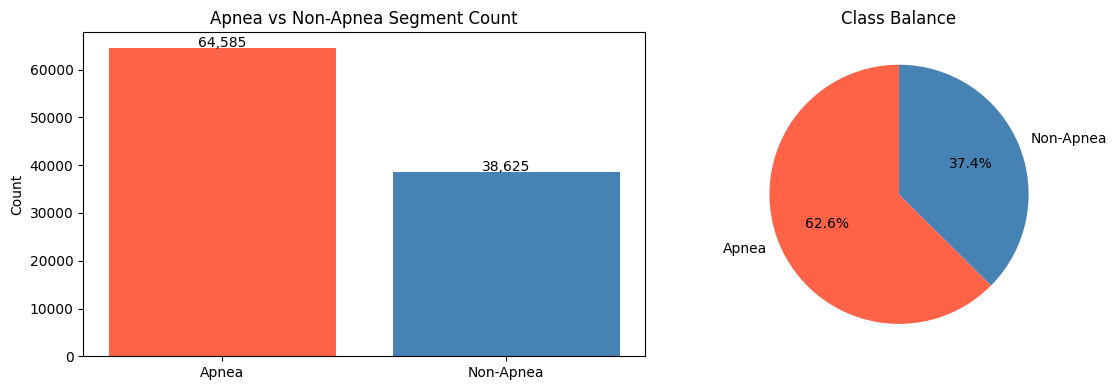

In [5]:
labels      = ["Apnea", "Non-Apnea"]
counts      = [total_ap, total_nap]
colors      = ["tomato", "steelblue"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(labels, counts, color=colors)
axes[0].set_title("Apnea vs Non-Apnea Segment Count")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts):
    axes[0].text(i, v + 200, f"{v:,}", ha="center")

# Pie chart
axes[1].pie(counts, labels=labels, colors=colors, autopct="%1.1f%%", startangle=90)
axes[1].set_title("Class Balance")

plt.tight_layout()
plt.show()

## 3. Apnea Type Distribution

=== Apnea Type Distribution ===
  Type 1 (OSA): 12,487 segments (19.3%)
  Type 2 (CSA): 10,859 segments (16.8%)
  Type 3 (Mixed/Hypopnea): 39,053 segments (60.5%)
  Type 4 (Other): 2,186 segments (3.4%)


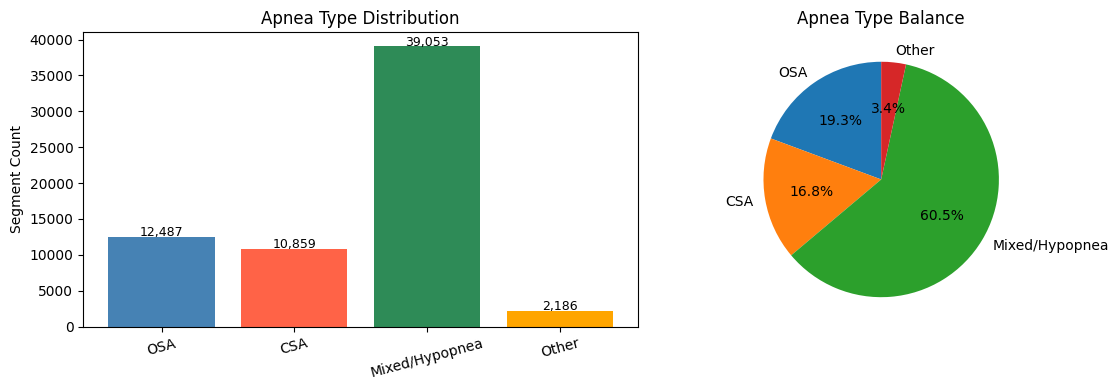

In [6]:
unique_types, type_counts = np.unique(all_types, return_counts=True)
type_labels = [APNEA_TYPE_NAMES.get(t, f"Type {t}") for t in unique_types]

print("=== Apnea Type Distribution ===")
for t, c, l in zip(unique_types, type_counts, type_labels):
    print(f"  Type {t} ({l}): {c:,} segments ({100*c/total_ap:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(type_labels, type_counts, color=["steelblue", "tomato", "seagreen", "orange"][:len(unique_types)])
axes[0].set_title("Apnea Type Distribution")
axes[0].set_ylabel("Segment Count")
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(type_counts):
    axes[0].text(i, v + 100, f"{v:,}", ha="center", fontsize=9)

axes[1].pie(type_counts, labels=type_labels, autopct="%1.1f%%", startangle=90)
axes[1].set_title("Apnea Type Balance")

plt.tight_layout()
plt.show()

## 4. Segments per Subject

=== Apnea Segments per Subject ===
Min : 13
Max : 797
Mean: 336.4
Std : 177.8


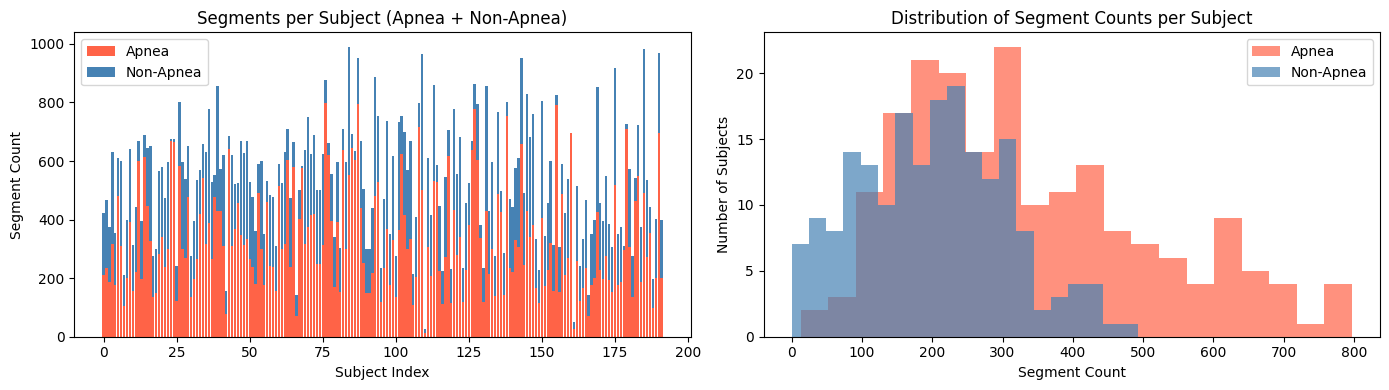

In [7]:
print("=== Apnea Segments per Subject ===")
print(f"Min : {df_subj['n_ap'].min()}")
print(f"Max : {df_subj['n_ap'].max()}")
print(f"Mean: {df_subj['n_ap'].mean():.1f}")
print(f"Std : {df_subj['n_ap'].std():.1f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(range(len(df_subj)), df_subj["n_ap"], color="tomato", label="Apnea")
axes[0].bar(range(len(df_subj)), df_subj["n_nap"], bottom=df_subj["n_ap"], color="steelblue", label="Non-Apnea")
axes[0].set_title("Segments per Subject (Apnea + Non-Apnea)")
axes[0].set_xlabel("Subject Index")
axes[0].set_ylabel("Segment Count")
axes[0].legend()

axes[1].hist(df_subj["n_ap"], bins=20, color="tomato", alpha=0.7, label="Apnea")
axes[1].hist(df_subj["n_nap"], bins=20, color="steelblue", alpha=0.7, label="Non-Apnea")
axes[1].set_title("Distribution of Segment Counts per Subject")
axes[1].set_xlabel("Segment Count")
axes[1].set_ylabel("Number of Subjects")
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Waveform Visualisation — Apnea vs Non-Apnea

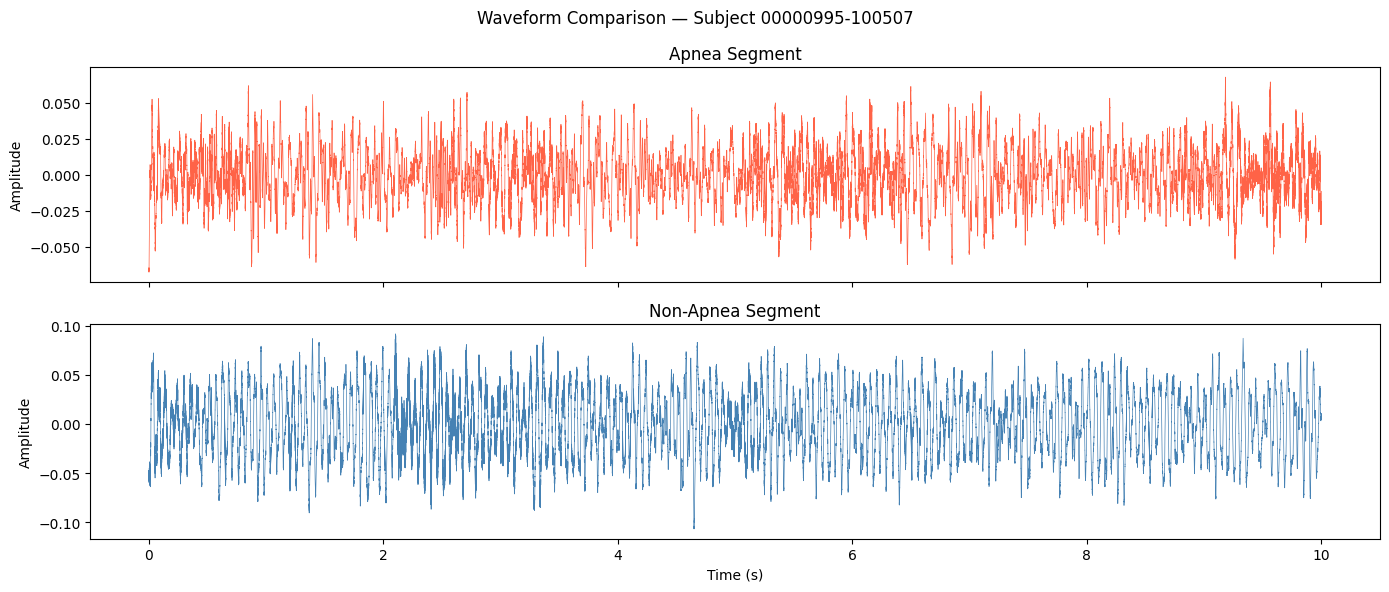

In [8]:
# Load one subject for visualisation
sample_subj = subjects[0]
ap  = np.load(PSG_DIR / sample_subj / f"{sample_subj}_ap.npy",  allow_pickle=True).astype(np.float32)
nap = np.load(PSG_DIR / sample_subj / f"{sample_subj}_nap.npy", allow_pickle=True).astype(np.float32)

time_axis = np.linspace(0, SEGMENT_LEN / SAMPLE_RATE, SEGMENT_LEN)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
fig.suptitle(f"Waveform Comparison — Subject {sample_subj}", fontsize=12)

axes[0].plot(time_axis, ap[0], color="tomato", linewidth=0.5)
axes[0].set_title("Apnea Segment")
axes[0].set_ylabel("Amplitude")

axes[1].plot(time_axis, nap[0], color="steelblue", linewidth=0.5)
axes[1].set_title("Non-Apnea Segment")
axes[1].set_ylabel("Amplitude")
axes[1].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

## 6. Mel Spectrogram — Apnea vs Non-Apnea

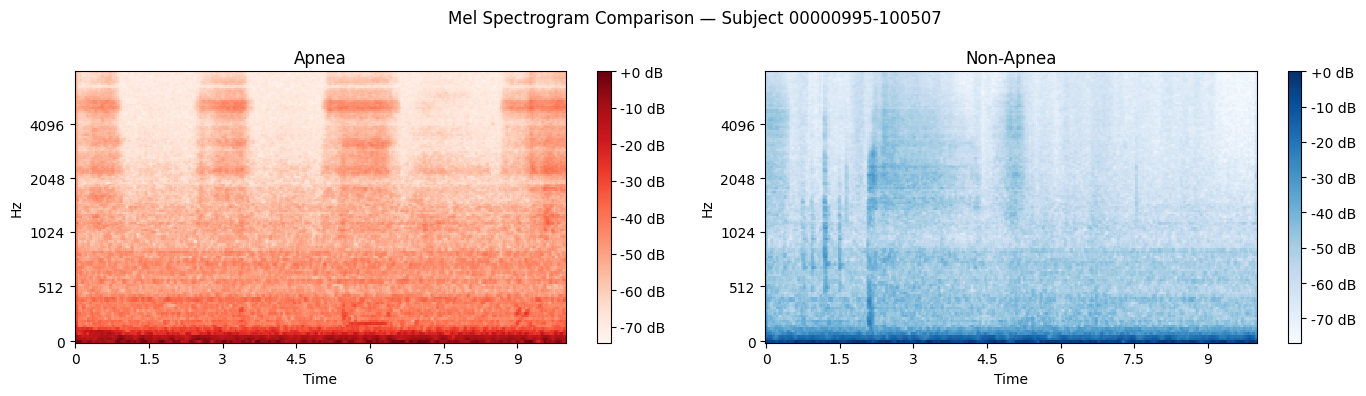

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle(f"Mel Spectrogram Comparison — Subject {sample_subj}", fontsize=12)

for ax, segment, title, color in zip(
    axes,
    [ap[0], nap[0]],
    ["Apnea", "Non-Apnea"],
    ["Reds", "Blues"]
):
    mel = librosa.feature.melspectrogram(y=segment, sr=SAMPLE_RATE, n_mels=128, fmax=8000)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    img = librosa.display.specshow(mel_db, sr=SAMPLE_RATE, x_axis="time", y_axis="mel", fmax=8000, ax=ax, cmap=color)
    ax.set_title(title)
    fig.colorbar(img, ax=ax, format="%+2.0f dB")

plt.tight_layout()
plt.show()

## 7. MFCC — Apnea vs Non-Apnea

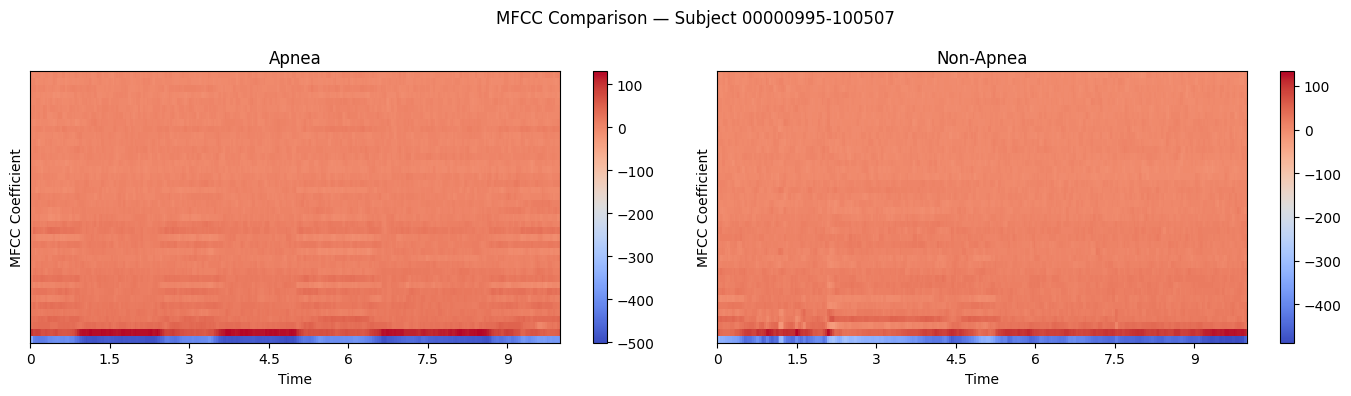

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle(f"MFCC Comparison — Subject {sample_subj}", fontsize=12)

for ax, segment, title in zip(axes, [ap[0], nap[0]], ["Apnea", "Non-Apnea"]):
    mfcc = librosa.feature.mfcc(y=segment, sr=SAMPLE_RATE, n_mfcc=40)
    img  = librosa.display.specshow(mfcc, sr=SAMPLE_RATE, x_axis="time", ax=ax)
    ax.set_title(title)
    ax.set_ylabel("MFCC Coefficient")
    fig.colorbar(img, ax=ax)

plt.tight_layout()
plt.show()

## 8. Apnea Type Waveform Comparison

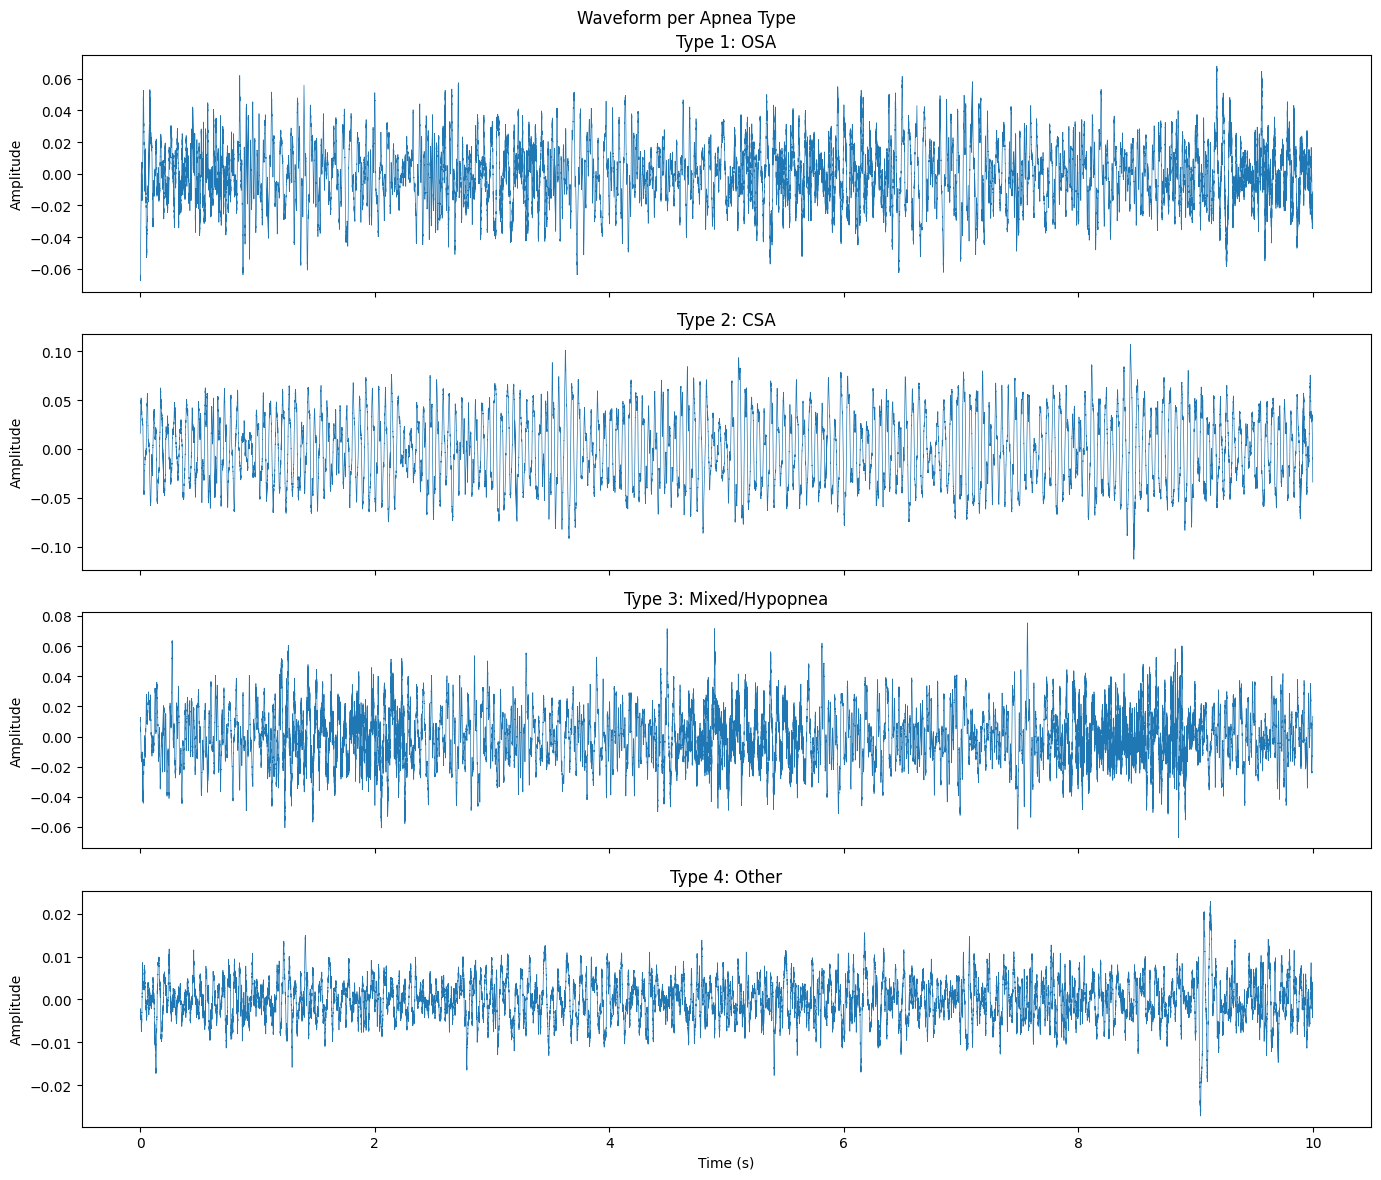

In [11]:
# Find one example segment per apnea type
type_examples = {}
for subj in subjects:
    types_file = AP_TYPES_DIR / f"{subj}_ap_types.npy"
    if not types_file.exists():
        continue
    types = np.load(types_file, allow_pickle=True)
    ap_data = np.load(PSG_DIR / subj / f"{subj}_ap.npy", allow_pickle=True).astype(np.float32)
    for t in APNEA_TYPE_NAMES:
        if t not in type_examples:
            idxs = np.where(types == t)[0]
            if len(idxs) > 0:
                type_examples[t] = ap_data[idxs[0]]
    if len(type_examples) == len(APNEA_TYPE_NAMES):
        break

n_types = len(type_examples)
fig, axes = plt.subplots(n_types, 1, figsize=(14, 3 * n_types), sharex=True)
fig.suptitle("Waveform per Apnea Type", fontsize=12)

for ax, (t, seg) in zip(axes, type_examples.items()):
    ax.plot(time_axis, seg, linewidth=0.5)
    ax.set_title(f"Type {t}: {APNEA_TYPE_NAMES[t]}")
    ax.set_ylabel("Amplitude")

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

## 9. Audio Statistics

In [12]:
print("=== Audio Segment Statistics (sample subject) ===")
for name, data in [("Apnea", ap), ("Non-Apnea", nap)]:
    flat = data.flatten()
    print(f"\n{name}:")
    print(f"  Shape : {data.shape}")
    print(f"  dtype : {data.dtype}")
    print(f"  Min   : {flat.min():.4f}")
    print(f"  Max   : {flat.max():.4f}")
    print(f"  Mean  : {flat.mean():.6f}")
    print(f"  Std   : {flat.std():.4f}")

=== Audio Segment Statistics (sample subject) ===

Apnea:
  Shape : (212, 160000)
  dtype : float32
  Min   : -0.1410
  Max   : 0.1177
  Mean  : 0.000016
  Std   : 0.0328

Non-Apnea:
  Shape : (212, 160000)
  dtype : float32
  Min   : -0.1520
  Max   : 0.1503
  Mean  : 0.000019
  Std   : 0.0285


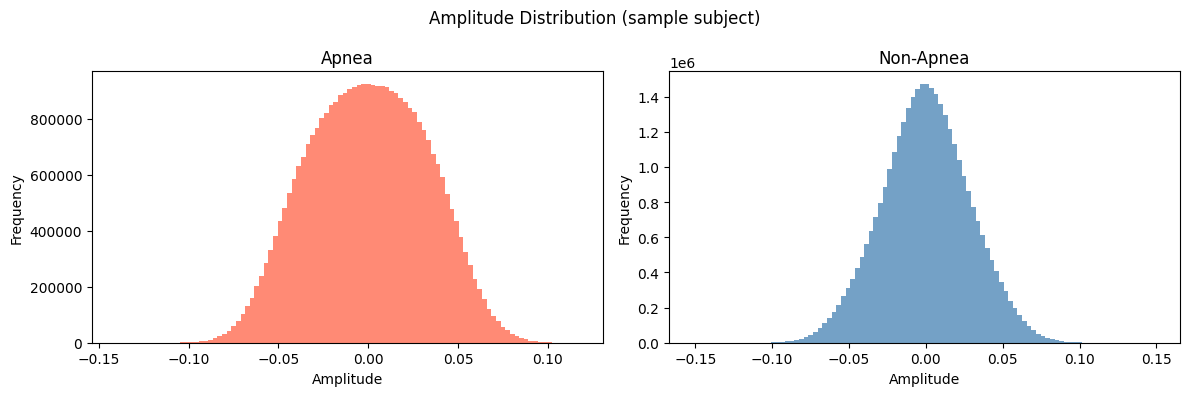

In [13]:
# Amplitude distribution across segments
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Amplitude Distribution (sample subject)")

for ax, data, label, color in zip(axes, [ap, nap], ["Apnea", "Non-Apnea"], ["tomato", "steelblue"]):
    ax.hist(data.flatten(), bins=100, color=color, alpha=0.75)
    ax.set_title(label)
    ax.set_xlabel("Amplitude")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## 10. RMS Energy — Apnea vs Non-Apnea

RMS Energy — Apnea    : mean=0.0321, std=0.0069
RMS Energy — Non-Apnea: mean=0.0273, std=0.0084


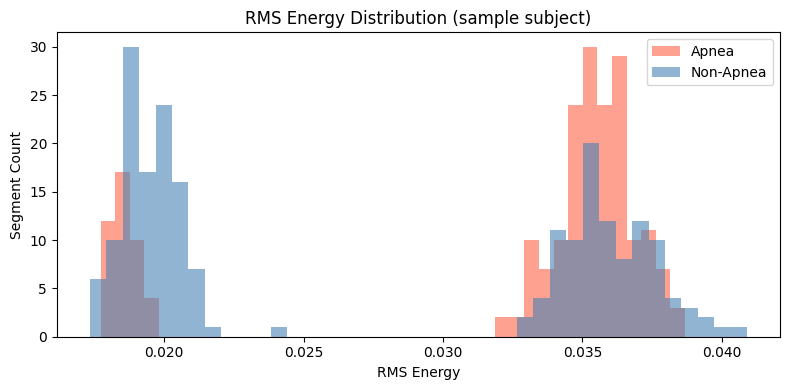

In [14]:
# RMS energy per segment is a simple proxy for loudness/activity
rms_ap  = np.sqrt(np.mean(ap**2,  axis=1))
rms_nap = np.sqrt(np.mean(nap**2, axis=1))

print(f"RMS Energy — Apnea    : mean={rms_ap.mean():.4f}, std={rms_ap.std():.4f}")
print(f"RMS Energy — Non-Apnea: mean={rms_nap.mean():.4f}, std={rms_nap.std():.4f}")

plt.figure(figsize=(8, 4))
plt.hist(rms_ap,  bins=40, color="tomato",    alpha=0.6, label="Apnea")
plt.hist(rms_nap, bins=40, color="steelblue", alpha=0.6, label="Non-Apnea")
plt.title("RMS Energy Distribution (sample subject)")
plt.xlabel("RMS Energy")
plt.ylabel("Segment Count")
plt.legend()
plt.tight_layout()
plt.show()

## 11. Data Quality Check

In [15]:
print("=== Data Quality Check ===")
print(f"Subjects missing nap.npy : {missing_nap}")
print()

# Check for silent segments (all zeros or near-zero RMS)
silence_threshold = 1e-4
silent_ap  = np.sum(np.sqrt(np.mean(ap**2,  axis=1)) < silence_threshold)
silent_nap = np.sum(np.sqrt(np.mean(nap**2, axis=1)) < silence_threshold)

print(f"Near-silent apnea segments (sample subject)    : {silent_ap}")
print(f"Near-silent non-apnea segments (sample subject): {silent_nap}")
print()

# Confirm ap and nap are always paired
mismatched = df_subj[df_subj['n_ap'] != df_subj['n_nap']]
print(f"Subjects where ap/nap counts differ: {len(mismatched)}")
if len(mismatched) > 0:
    print(mismatched)

=== Data Quality Check ===
Subjects missing nap.npy : ['00001408-100507']

Near-silent apnea segments (sample subject)    : 0
Near-silent non-apnea segments (sample subject): 0

Subjects where ap/nap counts differ: 76
             subject  n_ap  n_nap
5    00001010-100507   479    132
6    00001014-100507   310    289
9    00001020-100507   391    250
12   00001026-100507   600     67
14   00001037-100507   613     76
..               ...   ...    ...
182  00001461-100507   465     77
183  00001463-100507   548    176
186  00001478-100507   273    262
187  00001480-100507   355     88
190  00001492-100507   697    271

[76 rows x 3 columns]


## 12. Summary

| Property | Value |
|---|---|
| Subjects | 192 |
| Apnea segments | ~64,585 |
| Non-apnea segments | ~38,625 |
| Segment duration | ~10s at 16,000 Hz |
| Apnea types | OSA (1), CSA (2), Mixed/Hypopnea (3), Other (4) |
| Dominant type | Mixed/Hypopnea (~60%) |
| Paired structure | 1 non-apnea segment per apnea event per subject |
| Missing data | 1 subject missing nap.npy (00001408) |

**Key observations:**
- Class imbalance: ~62.5% apnea vs ~37.5% non-apnea — worth handling with weighted loss or oversampling
- Mixed/Hypopnea dominates the apnea type distribution
- Segments are pre-normalised (amplitude ~[-0.15, 0.15])
- RMS energy differences between apnea and non-apnea segments inform whether energy alone is discriminative
- Mel spectrogram is the more suitable feature representation based on visual separability